# Exp5.5.4 — Causal WHEN Phase Recovery

Analysis-only notebook. It reads finalized artifacts from `notebooks/artifacts/experiment_5_5_4_causal_when_phase_recovery/causal_when_phase_recovery_v1/`.


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
ART = ROOT / 'notebooks' / 'artifacts' / 'experiment_5_5_4_causal_when_phase_recovery' / 'causal_when_phase_recovery_v1'
runs = pd.read_csv(ART / 'runs.csv')
summary = pd.read_csv(ART / 'summary.csv')
paired = pd.read_csv(ART / 'paired_deltas.csv')
phase = pd.read_csv(ART / 'phase_metrics.csv')
confusion = pd.read_csv(ART / 'phase_confusion.csv')
routing = pd.read_csv(ART / 'routing_disagreement.csv')
margins = pd.read_csv(ART / 'margin_degradation.csv')
sensitivity = pd.read_csv(ART / 'phase_sensitivity.csv')
summary


,when,n_seeds,progress_mae_mean,progress_mae_sd,progress_spearman_mean,phase10_accuracy_mean,within1_bin_accuracy_mean,mean_abs_bin_error_mean,hard_test_ba_mean,hard_test_ba_sd,hard_test_ba_sem,local2_test_ba_mean,local2_test_ba_sd,local2_test_ba_sem
0,oracle,5,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.686642,0.038611,0.017267,0.688527,0.028894,0.012922
1,gru64_progress,5,0.097356,0.003340,0.907203,0.376253,0.772982,0.956267,0.411528,0.028691,0.012831,0.410574,0.036581,0.016360
2,rsnn64_progress,5,0.141929,0.002931,0.800613,0.218415,0.574198,1.445263,0.382221,0.064768,0.028965,0.392574,0.064480,0.028837


## 1. Progress MAE and Spearman

,progress_mae,progress_spearman
when,,
gru64_progress,0.097356,0.907203
rsnn64_progress,0.141929,0.800613


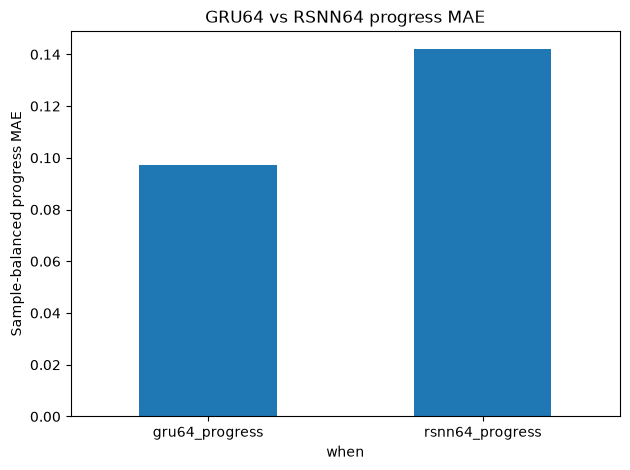

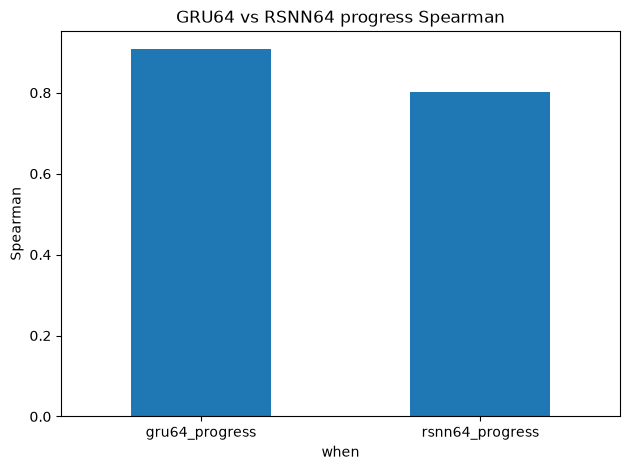

In [2]:
test_phase = phase[(phase['split'] == 'test') & (phase['when'] != 'oracle')]
agg = test_phase.groupby('when').agg(
    progress_mae=('sample_balanced_progress_mae', 'mean'),
    progress_spearman=('progress_spearman', 'mean'),
)
display(agg)
ax = agg['progress_mae'].plot(kind='bar', ylabel='Sample-balanced progress MAE', rot=0, title='GRU64 vs RSNN64 progress MAE')
plt.tight_layout()
plt.show()
ax = agg['progress_spearman'].plot(kind='bar', ylabel='Spearman', rot=0, title='GRU64 vs RSNN64 progress Spearman')
plt.tight_layout()
plt.show()


## 2. Phase10 and ±1-bin accuracy

,phase10,within1
when,,
gru64_progress,0.376253,0.772982
rsnn64_progress,0.218415,0.574198


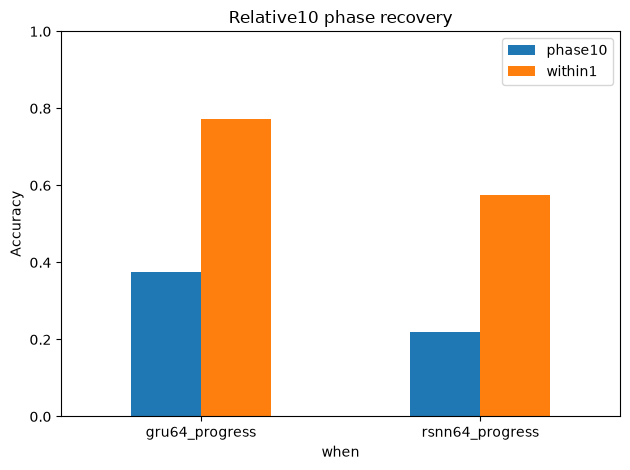

In [3]:
phase_acc = test_phase.groupby('when').agg(
    phase10=('sample_balanced_phase10_accuracy', 'mean'),
    within1=('sample_balanced_within1_bin_accuracy', 'mean'),
)
display(phase_acc)
phase_acc.plot(kind='bar', ylabel='Accuracy', rot=0, title='Relative10 phase recovery')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 3. Oracle / GRU / RSNN downstream test BA

routing,hard,local2
when,,
gru64_progress,0.411528,0.410574
oracle,0.686642,0.688527
rsnn64_progress,0.382221,0.392574


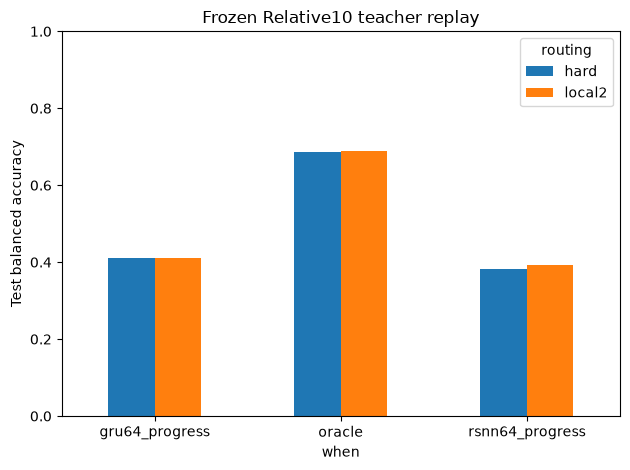

gap_oracle_minus_pred
architecture    routing                       
gru64_progress  hard                  0.275114
                local2                0.277953
rsnn64_progress hard                  0.304421
                local2                0.295953

In [4]:
ba = runs.groupby(['when', 'routing'])['test_balanced_accuracy'].mean().unstack('routing')
display(ba)
ba.plot(kind='bar', ylabel='Test balanced accuracy', rot=0, title='Frozen Relative10 teacher replay')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
display(paired.groupby(['architecture', 'routing'])[['gap_oracle_minus_pred']].mean())


## 4. Routing error vs oracle-margin loss

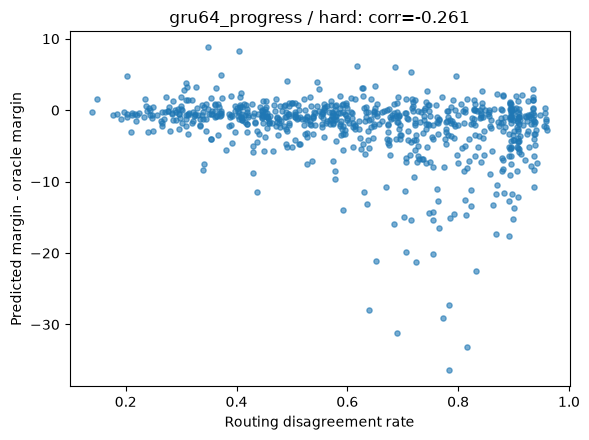

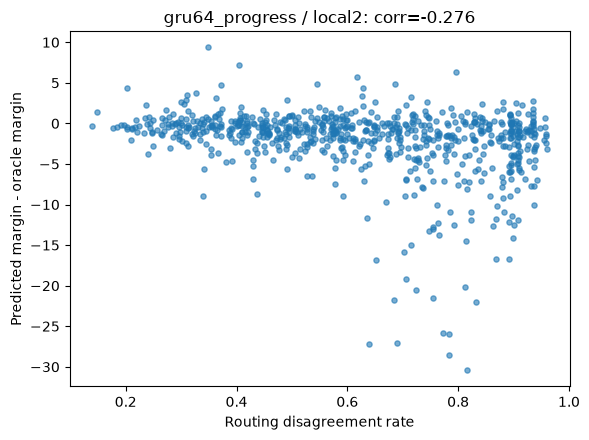

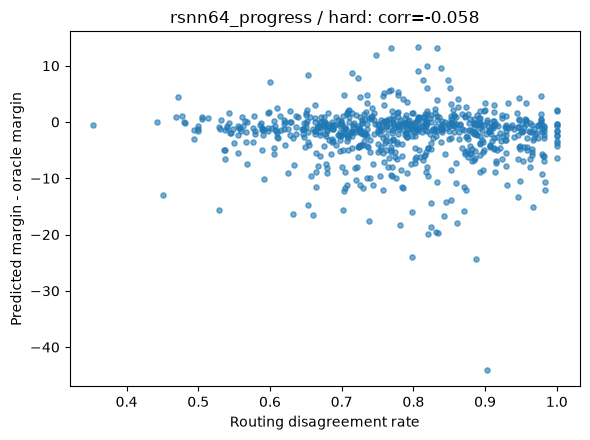

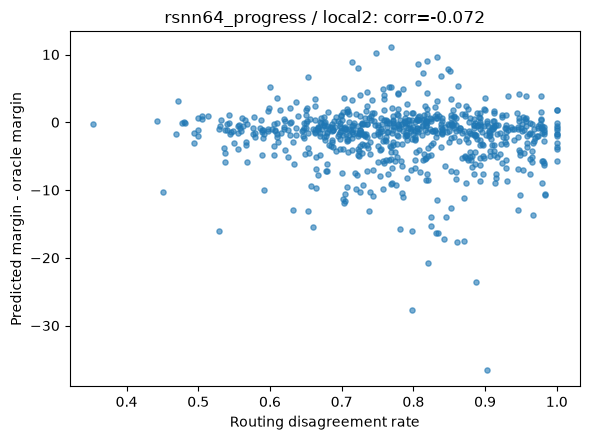

In [5]:
for (architecture, route), frame in margins.groupby(['architecture', 'routing']):
    fig, ax = plt.subplots(figsize=(6.0, 4.5))
    ax.scatter(frame['routing_disagreement_rate'], frame['margin_delta_pred_minus_oracle'], s=14, alpha=0.6)
    corr = frame[['routing_disagreement_rate', 'margin_delta_pred_minus_oracle']].corr().iloc[0, 1]
    ax.set_title(f'{architecture} / {route}: corr={corr:.3f}')
    ax.set_xlabel('Routing disagreement rate')
    ax.set_ylabel('Predicted margin - oracle margin')
    plt.tight_layout()
    plt.show()


## Additional diagnostics

In [6]:
display(confusion.groupby(['architecture', 'true_phase', 'predicted_phase'])['count'].sum().reset_index().head(20))
display(routing.groupby('architecture')[['routing_disagreement_rate', 'mean_abs_bin_error', 'within1_bin_accuracy']].mean())
display(sensitivity.groupby(['true_phase', 'substitute_phase'])['mean_evidence_l2'].mean().unstack('substitute_phase'))


,architecture,true_phase,predicted_phase,count
0,gru64_progress,0,0,4467
1,gru64_progress,0,1,1039
2,gru64_progress,0,2,144
3,gru64_progress,0,3,730
4,gru64_progress,0,4,0
5,gru64_progress,0,5,0
6,gru64_progress,0,6,0
7,gru64_progress,0,7,0
8,gru64_progress,0,8,0
9,gru64_progress,0,9,0


,routing_disagreement_rate,mean_abs_bin_error,within1_bin_accuracy
architecture,,,
gru64_progress,0.623747,0.956267,0.772982
rsnn64_progress,0.781585,1.445263,0.574198


substitute_phase,0,1,2,3,4,5,6,7,8,9
true_phase,,,,,,,,,,
0,0.000000,0.021184,0.021156,0.021440,0.021168,0.021903,0.022229,0.022921,0.023431,0.025830
1,0.146997,0.000000,0.080223,0.091542,0.086592,0.097819,0.091857,0.103828,0.136012,0.143304
2,0.390010,0.205875,0.000000,0.164054,0.177363,0.232652,0.222778,0.254931,0.338075,0.338952
3,0.534615,0.308831,0.223601,0.000000,0.197228,0.305036,0.325922,0.341982,0.407320,0.439440
4,0.656779,0.360719,0.274205,0.235910,0.000000,0.306819,0.340904,0.390784,0.495549,0.513413
5,0.730369,0.442411,0.389015,0.401624,0.322417,0.000000,0.319748,0.463183,0.586829,0.623740
6,0.802515,0.427122,0.374767,0.444381,0.369128,0.319442,0.000000,0.321391,0.472245,0.605530
7,0.779537,0.406454,0.366799,0.430271,0.407943,0.475057,0.330406,0.000000,0.345722,0.601013
8,0.748059,0.448567,0.497755,0.503346,0.517545,0.581790,0.477797,0.347476,0.000000,0.557762
